# Quadratic Equation IO-CRN Visual Check

Use this notebook to manually construct an IO-CRN and visually check whether its steady-state output approximates the positive root of `a*x^2 - b*x - c = 0` for nonnegative inputs `a, b, c` with `a > 0`.

In [1]:
import os, sys
from pathlib import Path
from RL4CRN.utils.crn_text_parser import reactions_from_text

os.environ.setdefault("MPLCONFIGDIR", "/tmp")

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "RL4CRN").exists() and (candidate / "apps").exists():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("Repo root:", repo_root)


Python: 3.10.12
Repo root: /local0/home/mfilo/git/GenAI-Net


## 1) Construct the CRN

Edit this cell. The rest of the notebook expects a compiled IOCRN named `candidate_crn` with three inputs `u_1, u_2, u_3` and one output, typically `X_6`.

In [2]:
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.input_interface import Configurator

cfg = Configurator.preset("paper")
cfg.solver.algorithm = "CVODE"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10

# hof_0 from the 6-species / 10-added-reaction quadratic-equation run.
# The first three reactions expose the coefficients as input-driven production:
#   u_1 = a, u_2 = b, u_3 = c.
# crn_text = """
# CRN hof_0, Reward: 0.1909286592422015 
# Inputs: ['u_1', 'u_2', 'u_3'] 
# Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6'] 
# Output Species: ['X_6'] 
# ∅ ----> X_1;  [MAK(1.0, u_1)]
# ∅ ----> X_2;  [MAK(1.0, u_2)]
# ∅ ----> X_3;  [MAK(1.0, u_3)]
# X_1 ----> X_3 + X_6;  [MAK(0.39422205090522766)]
# X_2 ----> X_6 + X_6;  [MAK(0.4535057842731476)]
# X_3 ----> X_6;  [MAK(0.4079498052597046)]
# X_3 ----> X_4 + X_4;  [MAK(0.4053219258785248)]
# X_1 + X_6 ----> X_1;  [MAK(0.40311625599861145)]
# X_1 + X_6 ----> X_1 + X_5;  [MAK(0.4166227877140045)]
# X_2 + X_3 ----> X_6 + X_6;  [MAK(0.37525293231010437)]
# X_2 + X_4 ----> X_6;  [MAK(0.4266620874404907)]
# X_2 + X_4 ----> X_6 + X_6;  [MAK(0.3628200590610504)]
# X_3 + X_3 ----> X_6;  [MAK(0.4321376383304596)]
# """

# crn_text = """
# CRN hof_0, Reward: 0.043657086235425184 
# Inputs: ['u_1', 'u_2', 'u_3'] 
# Species: ['X_1', 'X_2', 'X_3', 'X_5', 'X_6', 'X_8'] 
# Output Species: ['X_8'] 
# ∅ ----> X_1;  [MAK(1.0, u_1)]
# ∅ ----> X_2;  [MAK(1.0, u_2)]
# ∅ ----> X_3;  [MAK(1.0, u_3)]
# X_1 ----> X_6;  [MAK(2.931508779525757)]
# X_2 ----> X_8;  [MAK(2.9883177280426025)]
# X_3 ----> X_5 + X_8;  [MAK(3.0195658206939697)]
# X_1 + X_8 ----> X_1 + X_6;  [MAK(2.9436099529266357)]
# X_2 + X_3 ----> X_2 + X_8;  [MAK(2.9792659282684326)]
# X_2 + X_3 ----> X_8 + X_8;  [MAK(2.797053098678589)]
# X_2 + X_5 ----> X_5 + X_8;  [MAK(3.2559256553649902)]
# X_2 + X_6 ----> X_8;  [MAK(2.727231979370117)]
# X_3 + X_8 ----> X_8;  [MAK(3.001608371734619)]
# X_5 + X_8 ----> X_3 + X_8;  [MAK(2.7532076835632324)]
# """

crn_text = """
CRN hof_0, Reward: 0.029949688783080745 
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8'] 
Output Species: ['X_8'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> X_7;  [MAK(0.5315936803817749)]
X_2 ----> X_3 + X_8;  [MAK(0.44258299469947815)]
X_1 + X_8 ----> X_1 + X_3;  [MAK(0.20682312548160553)]
X_1 + X_8 ----> X_1 + X_5;  [MAK(0.5480917096138)]
X_2 + X_2 ----> X_6 + X_8;  [MAK(1.1097382307052612)]
X_2 + X_5 ----> X_3;  [MAK(1.4084287881851196)]
X_2 + X_7 ----> X_6 + X_6;  [MAK(0.28526726365089417)]
X_2 + X_8 ----> X_8 + X_8;  [MAK(0.35501185059547424)]
X_3 + X_3 ----> X_6;  [MAK(0.23603639006614685)]
X_3 + X_5 ----> X_8;  [MAK(1.0509811639785767)]
X_3 + X_6 ----> X_8;  [MAK(1.1450711488723755)]
X_3 + X_7 ----> X_8;  [MAK(0.44516831636428833)]
X_4 + X_5 ----> X_5 + X_5;  [MAK(0.2490413784980774)]
X_4 + X_7 ----> X_8;  [MAK(1.4126769304275513)]
X_5 + X_8 ----> X_2;  [MAK(0.4255014955997467)]
X_6 + X_6 ----> X_2 + X_6;  [MAK(1.7766610383987427)]
X_6 + X_6 ----> X_6 + X_8;  [MAK(0.2767406105995178)]
X_6 + X_7 ----> X_4 + X_5;  [MAK(0.4370608925819397)]
"""

reactions = reactions_from_text(crn_text)

candidate_crn = IOCRN(
    reactions,
    output_labels=["X_8"],
    solver=cfg.solver.algorithm,
    rtol=cfg.solver.rtol,
    atol=cfg.solver.atol,
)
candidate_crn.compile()

print(candidate_crn)
print("num_inputs:", candidate_crn.num_inputs)
# print("num_species:", candidate_crn.num_species)
# print("output_labels:", candidate_crn.output_labels)
# assert candidate_crn.num_inputs == 3


Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8'] 
Output Species: ['X_8'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> X_7;  [MAK(0.5315936803817749)]
X_2 ----> X_3 + X_8;  [MAK(0.44258299469947815)]
X_1 + X_8 ----> X_1 + X_3;  [MAK(0.20682312548160553)]
X_1 + X_8 ----> X_1 + X_5;  [MAK(0.5480917096138)]
X_2 + X_2 ----> X_6 + X_8;  [MAK(1.1097382307052612)]
X_2 + X_5 ----> X_3;  [MAK(1.4084287881851196)]
X_2 + X_7 ----> X_6 + X_6;  [MAK(0.28526726365089417)]
X_2 + X_8 ----> X_8 + X_8;  [MAK(0.35501185059547424)]
X_3 + X_3 ----> X_6;  [MAK(0.23603639006614685)]
X_3 + X_5 ----> X_8;  [MAK(1.0509811639785767)]
X_3 + X_6 ----> X_8;  [MAK(1.1450711488723755)]
X_3 + X_7 ----> X_8;  [MAK(0.44516831636428833)]
X_4 + X_5 ----> X_5 + X_5;  [MAK(0.2490413784980774)]
X_4 + X_7 ----> X_8;  [MAK(1.4126769304275513)]
X_5 + X_8 ----> X_2;  [MAK(0.4255014955997467)]
X_6 + X_6 ----> X_2 + X_6;  [MAK(1

In [3]:
# from RL4CRN.utils.symbolic_calculations import output_algebraic_equation
# result = output_algebraic_equation(
#     candidate_crn,
#     output_label="X_8",
#     input_labels=("u_1", "u_2", "u_3"),
#     use_numeric_parameters=False,
# )

# result["polynomial"]
# result["coefficients"]
# result["degree"]

In [4]:
# eta = 0.01; delta_3 = 0.1; eta_3 = 0.01; eta_3_prime = 0.1; delta_5 = 0.1; 
# eta_5 = 0.01; eta_5_prime = 0.1; eta_6 = 0.01; eta_6_prime = 0.1;
# theta_1 = eta_3_prime * delta_3 / eta_3;
# theta_2 = eta_6_prime * eta_5_prime * delta_5 / (eta_5 * eta_6);
# k = 1; gamma = 30.0;

# reactions = [
#     MassAction([], ["Z_1"], input_channels=["u_3"], params=[1.0]),
#     MassAction(["Z_1", "Z_2"], [], params=[eta]),
#     MassAction([], ["Z_3"], input_channels=["u_2"], params=[1.0]),
#     MassAction(["Z_3"], [], params=[delta_3]),
#     MassAction(["Z_3", "X_L"], ["Z_4"], params=[eta_3]),
#     MassAction(["Z_4"], ["Z_3", "X_L"], params=[eta_3_prime]),
#     MassAction(["Z_4"], ["Z_4", "Z_1"], params=[theta_1]),
#     MassAction([], ["Z_5"], input_channels=["u_1"], params=[1.0]),
#     MassAction(["Z_5"], [], params=[delta_5]),
#     MassAction(["Z_5", "X_L"], ["Z_6"], params=[eta_5]),
#     MassAction(["Z_6"], ["Z_5", "X_L"], params=[eta_5_prime]),
#     MassAction(["Z_6", "X_L"], ["Z_7"], params=[eta_6]),
#     MassAction(["Z_7"], ["Z_6", "X_L"], params=[eta_6_prime]),
#     MassAction(["Z_7"], ["Z_7", "Z_2"], params=[theta_2]),

#     MassAction(["Z_1"], ["Z_1", "X_L"], params=[k]),
#     MassAction(["X_L"], [], params=[gamma]),
# ]
# candidate_crn = IOCRN(
#     reactions,
#     output_labels=["X_L"],
#     solver=cfg.solver.algorithm,
#     rtol=cfg.solver.rtol,
#     atol=cfg.solver.atol,
# )
# candidate_crn.compile()

# print(candidate_crn)
# print("num_inputs:", candidate_crn.num_inputs)
# print("num_species:", candidate_crn.num_species)
# print("output_labels:", candidate_crn.output_labels)
# assert candidate_crn.num_inputs == 3

# reactions = [
#     MassAction([], ["X_1"], input_channels=["u_1"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_1"], [], params=[1.0], params_controllability=[True]),

#     MassAction([], ["X_2"], input_channels=["u_3"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_2"], [], params=[1.0], params_controllability=[True]),

#     MassAction(["X_1", "X_2"], ["X_3"], params=[4.0], params_controllability=[True]),
#     MassAction(["X_3"], ["X_1", "X_2"], params=[1.0], params_controllability=[True]),

#     MassAction([], ["X_4"], input_channels=["u_2"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_4"], [], params=[1.0], params_controllability=[True]),

#     MassAction(["X_4", "X_4"], ["X_5"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_5"], ["X_4", "X_4"], params=[1.0], params_controllability=[True]),

#     MassAction(["X_3"], ["X_3", "X_6"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_5"], ["X_5", "X_7"], params=[1.0], params_controllability=[True]),

#     MassAction(["X_6"], ["X_8"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_7"], ["X_8"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_8"], [], params=[1.0], params_controllability=[True]),

#     MassAction(["X_8"], ["X_8", "X_9"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_9", "X_9"], ["X_9"], params=[1.0], params_controllability=[True]),

#     MassAction(["X_9"], ["X_9", "X_10"], params=[1.0], params_controllability=[True]),
#     MassAction([], ["X_11"], input_channels=["u_2"], params=[1.0], params_controllability=[True]),

#     MassAction(["X_10"], ["X_12"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_11"], ["X_12"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_12"], [], params=[1.0], params_controllability=[True]),

#     MassAction(["X_12"], ["X_12", "X_13"], params=[1.0], params_controllability=[True]),

#     MassAction([], ["X_14"], input_channels=["u_1"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_14"], [], params=[1.0], params_controllability=[True]),

#     MassAction(["X_13", "X_15"], ["X_15", "X_15"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_15"], ["X_13"], params=[1.0], params_controllability=[True]),
#     MassAction(["X_14", "X_15"], ["X_14"], params=[2.0], params_controllability=[True]),
# ]

## 2) Evaluation Helpers

In [5]:
def quadratic_root(a, b, c):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)
    return (b + np.sqrt(b**2 + 4.0 * a * c)) / (2.0 * a)


def quadratic_residual(a, b, c, x):
    return a * x**2 - b * x - c


def make_input_grid(a_values, b_values, c_values):
    return [
        np.array([a, b, c], dtype=np.float32)
        for a in a_values
        for b in b_values
        for c in c_values
    ]


def make_random_inputs(n=300, a_range=(0.1, 1.0), b_range=(0.0, 1.0), c_range=(0.0, 1.0), seed=0):
    rng = np.random.default_rng(seed)
    a = rng.uniform(*a_range, size=n)
    b = rng.uniform(*b_range, size=n)
    c = rng.uniform(*c_range, size=n)
    return [np.array(u, dtype=np.float32) for u in np.column_stack([a, b, c])]


def evaluate_crn(crn, u_list, *, t_f=100.0, n_t=1000, ic_value=0.01, large_number=1e4):
    time_horizon = np.linspace(0.0, float(t_f), int(n_t), dtype=np.float32)
    x0 = np.full(crn.num_species, float(ic_value), dtype=np.float32)

    _, _, outputs, _ = crn.transient_response(
        u_list,
        [x0],
        time_horizon,
        LARGE_NUMBER=large_number,
        force=True,
    )

    rows = []
    for u, y in zip(u_list, outputs):
        a, b, c = [float(v) for v in np.asarray(u).reshape(-1)]
        x_pred = float(np.asarray(y)[0, -1])
        x_true = float(quadratic_root(a, b, c))
        abs_error = abs(x_pred - x_true)
        rel_error = abs_error / (abs(x_true) + 1e-12)
        residual = float(quadratic_residual(a, b, c, x_pred))
        rows.append({
            "a": a,
            "b": b,
            "c": c,
            "x_true": x_true,
            "x_pred": x_pred,
            "abs_error": abs_error,
            "rel_error": rel_error,
            "residual": residual,
            "abs_residual": abs(residual),
        })

    return pd.DataFrame(rows)


## 3) Generate Test Inputs

In [6]:
# A compact grid for interpretable slices. Keep a > 0 because the formula divides by a.
a_values = np.array([0.1, 0.3, 0.6, 1.0], dtype=float)
b_values = np.linspace(0.0, 1.0, 11)
c_values = np.linspace(0.0, 1.0, 11)

grid_inputs = make_input_grid(a_values, b_values, c_values)
random_inputs = make_random_inputs(n=300, seed=1)

print("grid inputs:", len(grid_inputs))
print("random inputs:", len(random_inputs))


grid inputs: 484
random inputs: 300


## 4) Simulate the CRN

In [7]:
df_grid = evaluate_crn(candidate_crn, grid_inputs, t_f=1000.0, n_t=1000, ic_value=0.01)
df_random = evaluate_crn(candidate_crn, random_inputs, t_f=1000.0, n_t=1000, ic_value=0.01)

display(df_grid.head())
display(df_random[["abs_error", "rel_error", "abs_residual"]].describe())


,a,b,c,x_true,x_pred,abs_error,rel_error,residual,abs_residual
0,0.1,0.0,0.0,0.000000,2.043151e-13,2.043151e-13,0.204315,4.174467e-27,4.174467e-27
1,0.1,0.0,0.1,1.000000,8.876599e-01,1.123401e-01,0.112340,-2.120599e-02,2.120599e-02
2,0.1,0.0,0.2,1.414214,1.294611e+00,1.196021e-01,0.084571,-3.239811e-02,3.239811e-02
3,0.1,0.0,0.3,1.732051,1.666939e+00,6.511145e-02,0.037592,-2.213132e-02,2.213132e-02
4,0.1,0.0,0.4,2.000000,2.026606e+00,2.660591e-02,0.013303,1.071315e-02,1.071315e-02


,abs_error,rel_error,abs_residual
count,300.000000,300.000000,300.000000
mean,0.097363,0.047537,0.097999
std,0.152703,0.051666,0.153892
min,0.000138,0.000074,0.000165
25%,0.017597,0.011313,0.021385
50%,0.046810,0.031589,0.048493
75%,0.097485,0.066193,0.102471
max,0.988261,0.386512,1.151822


## 5) Parity Plot and Error Distributions

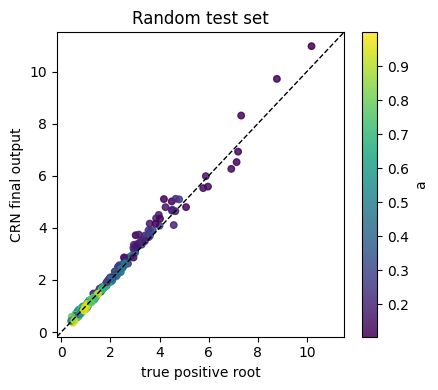

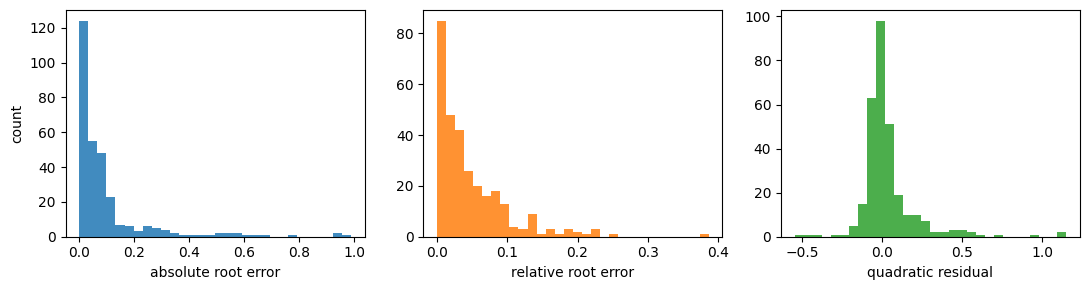

In [8]:
def plot_parity(df, color_by="abs_error", title="Predicted vs true root"):
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    sc = ax.scatter(df["x_true"], df["x_pred"], c=df[color_by], s=22, cmap="viridis", alpha=0.85)
    lo = min(df["x_true"].min(), df["x_pred"].min())
    hi = max(df["x_true"].max(), df["x_pred"].max())
    pad = 0.05 * max(hi - lo, 1e-12)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", linewidth=1.0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("true positive root")
    ax.set_ylabel("CRN final output")
    ax.set_title(title)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(color_by)
    fig.tight_layout()
    return fig, ax


def plot_error_histograms(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
    axes[0].hist(df["abs_error"], bins=30, color="C0", alpha=0.85)
    axes[0].set_xlabel("absolute root error")
    axes[0].set_ylabel("count")
    axes[1].hist(df["rel_error"], bins=30, color="C1", alpha=0.85)
    axes[1].set_xlabel("relative root error")
    axes[2].hist(df["residual"], bins=30, color="C2", alpha=0.85)
    axes[2].set_xlabel("quadratic residual")
    fig.tight_layout()
    return fig, axes


plot_parity(df_random, color_by="a", title="Random test set")
plot_error_histograms(df_random)
plt.show()


## 6) Error Heatmaps Over b,c at Fixed a

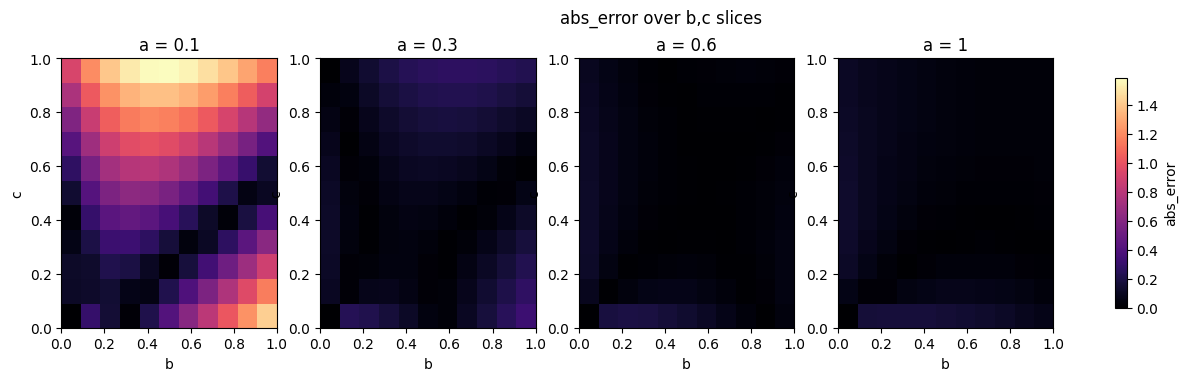

In [9]:
def plot_error_heatmaps(df, a_values_to_plot=None, value="abs_error"):
    if a_values_to_plot is None:
        a_values_to_plot = sorted(df["a"].unique())
    a_values_to_plot = list(a_values_to_plot)

    fig, axes = plt.subplots(1, len(a_values_to_plot), figsize=(4.0 * len(a_values_to_plot), 3.5), squeeze=False)
    vmax = df[value].max()

    for ax, a0 in zip(axes[0], a_values_to_plot):
        sub = df[np.isclose(df["a"], a0)].copy()
        table = sub.pivot(index="c", columns="b", values=value).sort_index(ascending=True)
        im = ax.imshow(
            table.values,
            origin="lower",
            aspect="auto",
            extent=[table.columns.min(), table.columns.max(), table.index.min(), table.index.max()],
            vmin=0.0,
            vmax=vmax,
            cmap="magma",
        )
        ax.set_title(f"a = {a0:g}")
        ax.set_xlabel("b")
        ax.set_ylabel("c")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(value)
    fig.suptitle(f"{value} over b,c slices", y=1.02)
    return fig, axes


plot_error_heatmaps(df_grid, a_values_to_plot=a_values, value="abs_error")
plt.show()


## 7) Line Slices

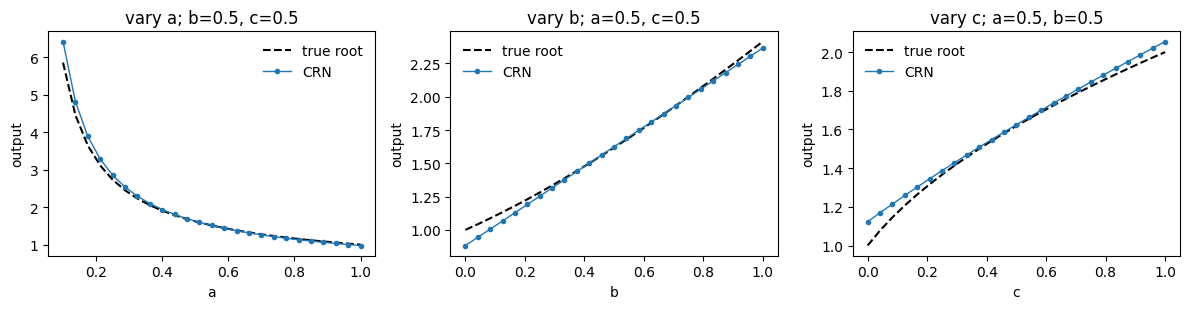

In [10]:
def evaluate_line_slice(crn, varying, values, fixed, *, t_f=100.0, n_t=1000, ic_value=0.01):
    order = ["a", "b", "c"]
    u_list = []
    for val in values:
        row = dict(fixed)
        row[varying] = float(val)
        u_list.append(np.array([row[name] for name in order], dtype=np.float32))
    df = evaluate_crn(crn, u_list, t_f=t_f, n_t=n_t, ic_value=ic_value)
    df[varying] = values
    return df


def plot_line_slices(crn):
    slices = [
        ("a", np.linspace(0.1, 1.0, 25), {"b": 0.5, "c": 0.5}),
        ("b", np.linspace(0.0, 1.0, 25), {"a": 0.5, "c": 0.5}),
        ("c", np.linspace(0.0, 1.0, 25), {"a": 0.5, "b": 0.5}),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
    for ax, (varying, values, fixed) in zip(axes, slices):
        df = evaluate_line_slice(crn, varying, values, fixed)
        ax.plot(values, df["x_true"], "k--", linewidth=1.5, label="true root")
        ax.plot(values, df["x_pred"], "o-", markersize=3.0, linewidth=1.0, label="CRN")
        fixed_text = ", ".join(f"{k}={v:g}" for k, v in fixed.items())
        ax.set_title(f"vary {varying}; {fixed_text}")
        ax.set_xlabel(varying)
        ax.set_ylabel("output")
        ax.legend(frameon=False)

    fig.tight_layout()
    return fig, axes


plot_line_slices(candidate_crn)
plt.show()


## 8) Worst Cases

In [11]:
cols = ["a", "b", "c", "x_true", "x_pred", "abs_error", "rel_error", "residual"]
display(df_random.sort_values("abs_error", ascending=False)[cols].head(10))
display(df_random.sort_values("abs_residual", ascending=False)[cols].head(10))


,a,b,c,x_true,x_pred,abs_error,rel_error,residual
194,0.123836,0.777817,0.945931,7.323978,8.312239,0.988261,0.134935,1.144910
176,0.115051,0.903896,0.931178,8.778501,9.719312,0.940811,0.107172,1.151822
184,0.115145,0.288754,0.803631,4.178177,5.105307,0.927130,0.221898,0.723336
93,0.105242,0.987439,0.863602,10.187992,10.975164,0.787172,0.077265,0.975949
61,0.106383,0.051674,0.819692,3.029285,3.716827,0.687542,0.226965,0.457900
216,0.130503,0.887733,0.107705,6.921628,6.263777,0.657851,0.095043,-0.547992
263,0.119317,0.834029,0.125390,7.137242,6.525028,0.612214,0.085777,-0.487395
275,0.173841,0.232801,0.998880,3.158418,3.740629,0.582212,0.184336,0.562726
210,0.167690,0.370442,0.838891,3.599068,4.163531,0.564463,0.156836,0.525666
292,0.159007,0.497213,0.754067,4.244328,4.794080,0.549752,0.129526,0.516743


,a,b,c,x_true,x_pred,abs_error,rel_error,residual
176,0.115051,0.903896,0.931178,8.778501,9.719312,0.940811,0.107172,1.151822
194,0.123836,0.777817,0.945931,7.323978,8.312239,0.988261,0.134935,1.144910
93,0.105242,0.987439,0.863602,10.187992,10.975164,0.787172,0.077265,0.975949
184,0.115145,0.288754,0.803631,4.178177,5.105307,0.927130,0.221898,0.723336
198,0.214859,0.791800,0.971904,4.656618,5.115714,0.459096,0.098590,0.600438
275,0.173841,0.232801,0.998880,3.158418,3.740629,0.582212,0.184336,0.562726
216,0.130503,0.887733,0.107705,6.921628,6.263777,0.657851,0.095043,-0.547992
247,0.187944,0.501930,0.862040,3.859153,4.367112,0.507959,0.131624,0.530384
210,0.167690,0.370442,0.838891,3.599068,4.163531,0.564463,0.156836,0.525666
55,0.173397,0.485204,0.807027,3.970436,4.497607,0.527172,0.132774,0.518280
